In [ ]:
import numpy as np
from scipy.fft import fft, fftshift, fftfreq
import matplotlib.pyplot as plt
import sympy as sp
from scipy.signal import chirp
#!pip install OptiCommPy
from IPython.display import display, Math, Latex
from optic.dsp.core import firFilter, signal_power, pulseShape, upsample
from optic.utils import parameters, dBm2W
from optic.models.devices import mzm, photodiode
from optic.plot import eyediagram

### Exemplo 1 - Taxa de amostragem
---

In [ ]:
def sincInterp(x, fa):

    fa_sinc = 32*fa
    Ta_sinc = 1/fa_sinc
    Ta = 1/fa
    t = np.arange(0, x.size*32)*Ta_sinc

    y = upsample(x,32)
    y[y==0] = np.nan

    x_sum = 0
    for k in range(0, x.size):
        xk_interp = x[k]*np.sinc((t-k*Ta)/Ta)
        x_sum += xk_interp

    return x_sum, t

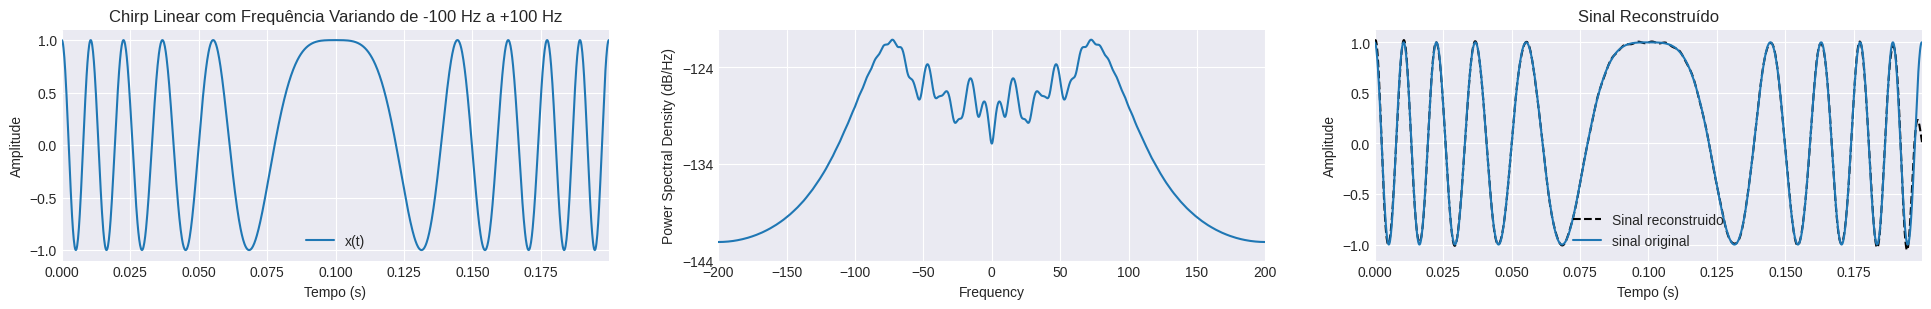

In [ ]:
Fa = 400    #frequencia de amostragem
Ta = 1/Fa   # taxa de amostragem
B = 100     # Intervalo do espectro na frequencia

t = np.arange(0, 0.2,Ta/16)     #duração do sinal
d = t.size/2                    #deixa o sinal simetrico
x = chirp(t, f0=-100, f1=100, t1=max(t), method='linear') #criando o sinal

# Realizando a amostragem do sinal
xa = x[::16]
ta = t[::16]

# Plot do sinal
plt.style.use('seaborn-v0_8-darkgrid')
fig, axis = plt.subplots(1, 3 , figsize=(24,3))
axis[0].plot(t, x, label="x(t)")
axis[0].set_title("Chirp Linear com Frequência Variando de -100 Hz a +100 Hz")
axis[0].set_xlabel("Tempo (s)")
axis[0].set_ylabel("Amplitude")
axis[0].set_xlim(min(t), max(t))
axis[0].legend(loc='best')

# plota psd
axis[1].psd(xa, Fs=Fa, NFFT = 16*1024, sides='twosided')
axis[1].set_xlim(-Fa/2, Fa/2)

x_int, t_int = sincInterp(xa, Fa)

axis[2].plot(t_int, x_int, "--k", label="Sinal reconstruido")
axis[2].set_title("Sinal Reconstruído")
axis[2].plot(t,x, label="sinal original")
axis[2].set_xlim(min(t), max(t))
axis[2].set_xlabel("Tempo (s)")
axis[2].set_ylabel("Amplitude")
axis[2].legend(loc='best')

plt.show()

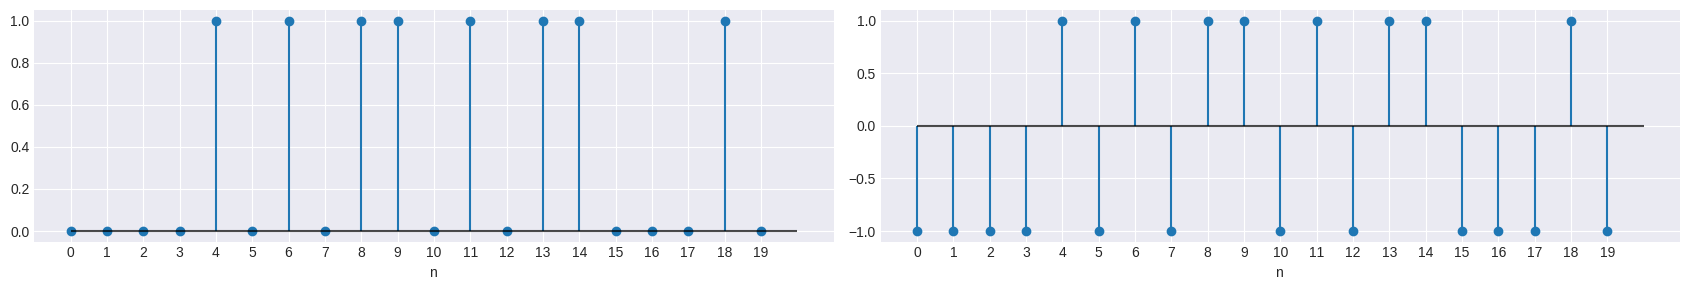

In [ ]:
bits = np.random.randint(2,size=20)
n = np.arange(0,bits.size)

#mapeia bits para simbolos binarios para gerar sinais eletricos.
symb = 2*bits-1

fig, axis = plt.subplots(1, 2, figsize=(17, 3))
plt.style.use("seaborn-v0_8-darkgrid")

axis[0].stem(bits, basefmt=" ")
axis[0].set_xlabel("n")
axis[0].set_xticks(n)
axis[0].hlines(0, 0, 20, color="k", alpha=0.7)

axis[1].stem(symb, basefmt=" ")
axis[1].set_xlabel("n")
axis[1].set_xticks(n)
axis[1].hlines(0, 0, 20, color="k", alpha=0.7)

plt.tight_layout()
plt.show()

In [ ]:
# parâmetros da simulação
SpS = 128                                       # Parametros de amostra por simbolo
Rs = 10e9                                       # Taxa de simbolos
Ts = 1/Rs                                       # Periodo de simbolos
Fa = 1/(Ts/SpS)                                 # fr de amostragem
Ta = 1/Fa                                       # per de amostragem

# pulso NRZ típico
pulse = pulseShape("nrz",SpS)
pulse = pulse/max(np.abs(pulse))

# pulso cosseno levantado (raised cosine)
Ncoeffs = 1000
rolloff = 0.01

pulse2 = pulseShape('rc', SpS, Ncoeffs, rolloff, Ts)
pulse2 = pulse2/max(abs(pulse2))

In [ ]:
# Aumenta a taxa de amostragem, acrescentando zeros.
symbolsUp = upsample(symb, SpS).astype(np.float64)

# formatação de pulso NRZ e Cosseno levantado
sigft = firFilter(pulse, symbolsUp)
sigft2 = firFilter(pulse2, symbolsUp)
sigft = sigft.real
sigft2 = sigft2.real
t1 = np.arange(0, sigft.size)*(Ta/1e-12)

# instantes centrais dos intervalos de sinalização
symbolsUp[symbolsUp==0] = np.nan
t2 = (np.arange(0, symb.size))*(Ts/1e-12)

paramMZM = parameters()
paramMZM.Vpi = 2
paramMZM.Vb = (-paramMZM.Vpi/2)

P0 = 100e-3 # potência da portadora CW na entrada no MZM
Ai = np.sqrt(P0)
sigft0 = mzm(Ai, (-paramMZM.Vb)*sigft, paramMZM)
sigft20 = mzm(Ai, (-paramMZM.Vb)*sigft2, paramMZM)
t3 = np.arange(0, sigft0.size)*(Ta/1e-12)

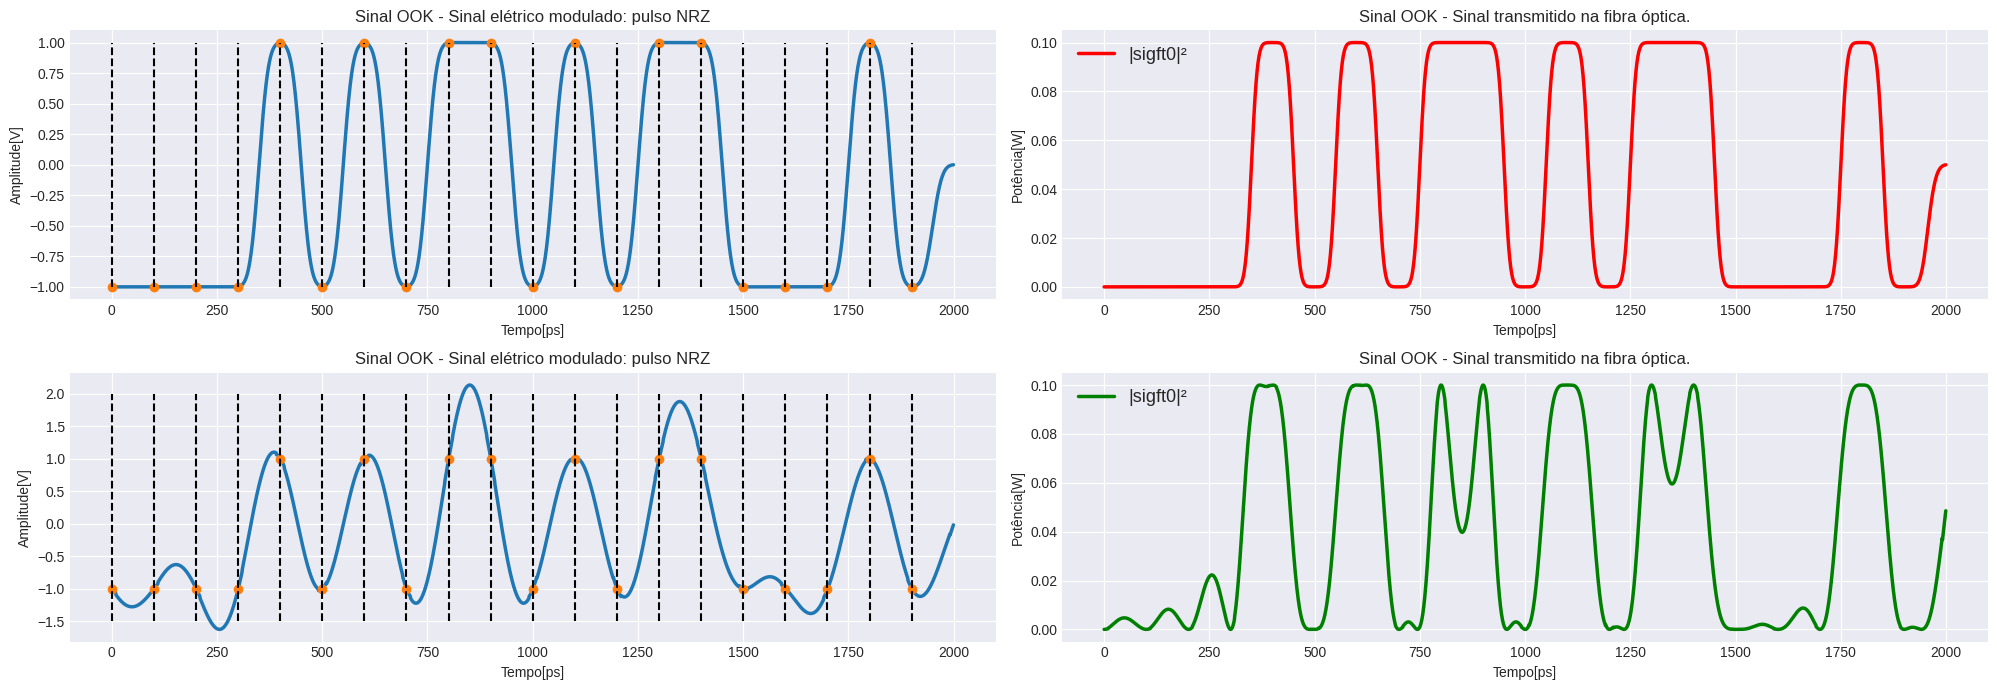

In [ ]:
plt.style.use("seaborn-v0_8-darkgrid")
fig, axis = plt.subplots(2, 2, figsize=(20, 7))

axis[0,0].plot(t1, sigft, "-", linewidth = 2.5)
axis[0,0].plot(t1, symbolsUp, "o", linewidth = 2.5)
axis[0,0].vlines(t2, -1, 1, linestyles='dashed', color = 'k')
axis[0,0].set_xlabel("Tempo[ps]")
axis[0,0].set_ylabel("Amplitude[V]")
axis[0,0].set_title("Sinal OOK - Sinal elétrico modulado: pulso NRZ")

axis[0,1].plot(t3, np.abs(sigft0)**2, linewidth = 2.5, label = "|sigft0|²", color="r")
axis[0,1].set_xlabel("Tempo[ps]")
axis[0,1].set_ylabel("Potência[W]")
axis[0,1].set_title("Sinal OOK - Sinal transmitido na fibra óptica.")
axis[0,1].legend(loc="best", fontsize = 13)

axis[1,0].plot(t1, sigft2, "-", linewidth = 2.5)
axis[1,0].plot(t1, symbolsUp, "o", linewidth = 2.5)
axis[1,0].vlines(t2, -1.5, 2, linestyles='dashed', color = 'k')
axis[1,0].set_xlabel("Tempo[ps]")
axis[1,0].set_ylabel("Amplitude[V]")
axis[1,0].set_title("Sinal OOK - Sinal elétrico modulado: pulso NRZ")

axis[1,1].plot(t3, np.abs(sigft20)**2, linewidth = 2.5, label = "|sigft0|²", color="g")
axis[1,1].set_xlabel("Tempo[ps]")
axis[1,1].set_ylabel("Potência[W]")
axis[1,1].set_title("Sinal OOK - Sinal transmitido na fibra óptica.")
axis[1,1].legend(loc="best", fontsize = 13)

plt.tight_layout()
plt.show()